# Explainable Graph-Based Phishing URL Detection

## Object-Oriented Implementation

This notebook implements the proposed explainable phishing URL detection
framework using object-oriented programming.

The implementation consists of four main components:

1. ModelTrainer - Trains a model based on a random forest to phishing detection. 
2. PhishingGraph – manages the heterogeneous graph and BFS traversal.
3. EvidenceExtractor – extracts and aggregates graph-based evidence.
4. EvidenceRanker – scores and ranks evidence using the predefined scoring scheme.
5. ExplanationGenerator – converts ranked evidence into a human-readable explanation.

The classes are designed according to the architecture proposed in Part 1.

In [1]:
import networkx as nx
import pandas as pd
import ast

from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## 1. ModelTrainer Class

The ModelTrainer class manages dataset loading, feature selection,
train/test splitting, Random Forest training, prediction, and model
evaluation.

Configuration values such as the dataset path and machine-learning
features are encapsulated within the class.

In [2]:
class ModelTrainer:

    def __init__(self):
        """
        Initialise the model trainer.
        """

        self._dataset_path = (
            "../data/phiusill_enriched_10000.csv"
        )

        self._ml_features = [
            "URLLength",
            "DomainLength",
            "IsDomainIP",
            "URLSimilarityIndex",
            "CharContinuationRate",
            "URLCharProb",
            "TLDLength",
            "NoOfSubDomain",
            "HasObfuscation",
            "NoOfObfuscatedChar",
            "ObfuscationRatio",
            "NoOfLettersInURL",
            "LetterRatioInURL",
            "NoOfDegitsInURL",
            "DegitRatioInURL",
            "NoOfEqualsInURL",
            "NoOfQMarkInURL",
            "NoOfAmpersandInURL",
            "NoOfOtherSpecialCharsInURL",
            "SpacialCharRatioInURL",
            "IsHTTPS",
            "NoOfURLRedirect",
            "NoOfSelfRedirect",
            "NoOfSelfRef",
            "NoOfEmptyRef",
            "NoOfExternalRef"
        ]

        self._test_size = 0.20
        self._random_state = 42

        self._df = None
        self._df_graph = None

        self._X = None
        self._Y = None

        self._X_train = None
        self._X_test = None
        self._y_train = None
        self._y_test = None

        self._model = None

        self._y_pred = None
        self._y_proba = None

    def load_data(self):
        """
        Load the DNS-enriched dataset and convert
        list-based columns back to Python lists.
        """

        self._df = pd.read_csv(
            self._dataset_path
        )

        self._df["ip_addresses"] = (
            self._df["ip_addresses"]
            .apply(ast.literal_eval)
        )

        self._df["name_servers"] = (
            self._df["name_servers"]
            .apply(ast.literal_eval)
        )

        return self._df

    def prepare_data(self):
        """
        Keep records containing both IP addresses
        and name servers.
        """

        ip_present = (
            self._df["ip_addresses"].apply(len) > 0
        )

        ns_present = (
            self._df["name_servers"].apply(len) > 0
        )

        self._df_graph = self._df[
            ip_present & ns_present
        ].copy()

        self._X = self._df_graph[
            self._ml_features
        ]

        self._Y = self._df_graph[
            "is_phishing"
        ]

        return self._df_graph

    def split_data(self):
        """
        Split the data into training and testing sets.
        """

        self._X_train, self._X_test, \
        self._y_train, self._y_test = (
            train_test_split(
                self._X,
                self._Y,
                test_size=self._test_size,
                stratify=self._Y,
                random_state=self._random_state
            )
        )

    def train(self):
        """
        Train the Random Forest model.
        """

        self._model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=self._random_state,
            n_jobs=-1
        )

        self._model.fit(
            self._X_train,
            self._y_train
        )

        return self._model

    def predict(self):
        """
        Generate predictions and class probabilities.
        """

        self._y_pred = self._model.predict(
            self._X_test
        )

        self._y_proba = (
            self._model.predict_proba(
                self._X_test
            )
        )

        return (
            self._y_pred,
            self._y_proba
        )

    def evaluate(self):
        """
        Evaluate the trained Random Forest model.
        """

        accuracy = accuracy_score(
            self._y_test,
            self._y_pred
        )

        precision = precision_score(
            self._y_test,
            self._y_pred,
            pos_label=1
        )

        recall = recall_score(
            self._y_test,
            self._y_pred,
            pos_label=1
        )

        f1 = f1_score(
            self._y_test,
            self._y_pred,
            pos_label=1
        )

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

    def get_dataframe(self):
        return self._df_graph

    def get_model(self):
        return self._model

    def get_X_train(self):
        return self._X_train

    def get_X_test(self):
        return self._X_test

    def get_y_train(self):
        return self._y_train

    def get_y_test(self):
        return self._y_test

    def get_predictions(self):
        return self._y_pred

    def get_probabilities(self):
        return self._y_proba

## 2. PhishingGraph Class

The PhishingGraph class manages the heterogeneous phishing graph.

It encapsulates the NetworkX graph and provides graph traversal functionality.
Breadth-First Search (BFS) is used to explore the neighbourhood of a predicted
URL up to a predefined number of hops.

In [3]:
class PhishingGraph:

    def __init__(self, dataframe):
        """
        Initialise and construct the phishing graph.
        """

        self._dataframe = dataframe
        self._graph = nx.Graph()

        self._build_graph()

    def _build_graph(self):
        """
        Construct the complete heterogeneous graph.
        """

        self._add_url_nodes()
        self._add_domain_nodes()
        self._add_ip_nodes()
        self._add_name_server_nodes()

    def _add_url_nodes(self):
        """
        Add URL nodes.
        """

        for idx, row in self._dataframe.iterrows():

            url_node = f"url_{idx}"

            self._graph.add_node(
                url_node,
                node_type="url",
                url=row["URL"],
                is_phishing=row["is_phishing"]
            )

    def _add_domain_nodes(self):
        """
        Add domain nodes and URL-domain relationships.
        """

        for idx, row in self._dataframe.iterrows():

            url_node = f"url_{idx}"

            domain = row["registered_domain"]

            if pd.notna(domain) and domain != "":

                domain_node = (
                    f"domain_{domain}"
                )

                self._graph.add_node(
                    domain_node,
                    node_type="domain",
                    value=domain
                )

                self._graph.add_edge(
                    url_node,
                    domain_node,
                    relationship="HAS_DOMAIN"
                )

    def _add_ip_nodes(self):
        """
        Add IP nodes and URL-IP relationships.
        """

        for idx, row in self._dataframe.iterrows():

            url_node = f"url_{idx}"

            for ip in row["ip_addresses"]:

                if pd.notna(ip) and ip != "":

                    ip_node = f"ip_{ip}"

                    self._graph.add_node(
                        ip_node,
                        node_type="ip",
                        value=ip
                    )

                    self._graph.add_edge(
                        url_node,
                        ip_node,
                        relationship="RESOLVES_TO"
                    )

    def _add_name_server_nodes(self):
        """
        Add name-server nodes and URL-name-server relationships.
        """

        for idx, row in self._dataframe.iterrows():

            url_node = f"url_{idx}"

            for ns in row["name_servers"]:

                if pd.notna(ns) and ns != "":

                    ns_node = f"ns_{ns}"

                    self._graph.add_node(
                        ns_node,
                        node_type="name_server",
                        value=ns
                    )

                    self._graph.add_edge(
                        url_node,
                        ns_node,
                        relationship="USES_NAME_SERVER"
                    )

    def get_graph(self):
        """
        Return the constructed NetworkX graph.
        """

        return self._graph

    def number_of_nodes(self):
        return self._graph.number_of_nodes()

    def number_of_edges(self):
        return self._graph.number_of_edges()

    def bfs(self, start_node, max_depth=2):
        """
        Perform BFS from a starting node.
        """

        return nx.single_source_shortest_path_length(
            self._graph,
            start_node,
            cutoff=max_depth
        )

    def get_node_data(self, node):
        return self._graph.nodes[node]

    def shortest_path(self, source, target):
        return nx.shortest_path(
            self._graph,
            source,
            target
        )

    def add_predictions(
        self,
        indices,
        predictions,
        probabilities
    ):
        """
        Store Random Forest predictions and phishing
        probabilities on the corresponding URL nodes.
        """
    
        for idx, prediction, probability in zip(
            indices,
            predictions,
            probabilities
        ):
    
            url_node = f"url_{idx}"
    
            if url_node in self._graph:
    
                self._graph.nodes[
                    url_node
                ]["prediction"] = int(
                    prediction
                )
    
                self._graph.nodes[
                    url_node
                ]["prediction_probability"] = float(
                    probability
                )

## 3. EvidenceExtractor Class

The EvidenceExtractor class analyses the nodes discovered by BFS and converts
graph relationships into structured evidence.

It identifies direct relationships and shared infrastructure relationships.
Repeated shared infrastructure evidence is aggregated so that the same IP
address or name server is represented as a single evidence item.

In [4]:
class EvidenceExtractor:

    def __init__(self, graph_manager):
        """
        Initialise the evidence extractor.

        Parameters:
            graph_manager: PhishingGraph object.
        """
        self._graph_manager = graph_manager

    def extract(self, start_node, bfs_distances):
        """
        Extract evidence from BFS results.

        Returns:
            A list of structured evidence records.
        """

        graph = self._graph_manager.get_graph()

        evidence = []

        for node, distance in bfs_distances.items():

            if node == start_node:
                continue

            data = graph.nodes[node]
            node_type = data.get("node_type")

            # Direct infrastructure relationships
            if distance == 1 and node_type in {
                "ip",
                "name_server",
                "domain"
            }:

                evidence.append({
                    "evidence_type": f"direct_{node_type}",
                    "entity": data.get(
                        "value",
                        node
                    ),
                    "distance": distance,
                    "related_url": None,
                    "related_url_label": None,
                    "evidence_role": "context"
                })

            # URL reached through shared infrastructure
            elif distance == 2 and node_type == "url":

                path = self._graph_manager.shortest_path(
                    start_node,
                    node
                )

                if len(path) == 3:

                    relationship_node = path[1]

                    relationship_data = graph.nodes[
                        relationship_node
                    ]

                    evidence.append({
                        "evidence_type": (
                            f"shared_"
                            f"{relationship_data.get('node_type')}"
                        ),
                        "entity": relationship_data.get(
                            "value",
                            relationship_node
                        ),
                        "distance": distance,
                        "related_url": data.get("url"),
                        "related_url_label": data.get(
                            "is_phishing"
                        )
                    })

        return evidence

    def classify(self, evidence, known_training_indices):
        """
        Classify evidence according to whether the related URL
        is a known training-set phishing or legitimate URL.
        """

        graph = self._graph_manager.get_graph()

        for item in evidence:

            related_url = item.get("related_url")

            # Direct evidence has no related URL
            if related_url is None:
                item["evidence_role"] = "context"
                continue

            related_node = None

            for node, data in graph.nodes(data=True):

                if (
                    data.get("node_type") == "url"
                    and data.get("url") == related_url
                ):
                    related_node = node
                    break

            if related_node is None:
                item["evidence_role"] = "context"
                continue

            related_index = int(
                related_node.replace("url_", "")
            )

            # Avoid test-label leakage
            if related_index not in known_training_indices:

                item["evidence_role"] = "unavailable"

            elif graph.nodes[
                related_node
            ].get("is_phishing") == 1:

                item["evidence_role"] = "supporting"

            else:

                item["evidence_role"] = "neutral"

        return evidence

    def aggregate(self, evidence):
        """
        Aggregate repeated shared infrastructure evidence.

        Multiple URLs may be connected through the same IP address
        or name server. This method combines those relationships
        into a single evidence item.
        """

        aggregated = defaultdict(
            lambda: {
                "evidence_type": None,
                "entity": None,
                "distance": None,
                "known_phishing_urls": [],
                "known_legitimate_urls": []
            }
        )

        for item in evidence:

            if not item["evidence_type"].startswith("shared_"):
                continue

            key = (
                item["evidence_type"],
                item["entity"]
            )

            record = aggregated[key]

            record["evidence_type"] = item[
                "evidence_type"
            ]

            record["entity"] = item["entity"]

            record["distance"] = item["distance"]

            if item.get("evidence_role") == "supporting":

                record[
                    "known_phishing_urls"
                ].append(
                    item["related_url"]
                )

            elif item.get("evidence_role") == "neutral":

                record[
                    "known_legitimate_urls"
                ].append(
                    item["related_url"]
                )

        return list(aggregated.values())

## 4. EvidenceRanker Class

The EvidenceRanker class applies the predefined evidence scoring scheme
developed in Part 1.

Evidence is scored according to its relationship type and graph distance.
The resulting evidence records are then sorted in descending order.

In [5]:
class EvidenceRanker:

    def __init__(self):
        """
        Initialise the evidence scoring rules.
        """

        self._evidence_type_scores = {
            "shared_ip": 5,
            "shared_name_server": 4,
            "suspicious_url_keyword": 3,
            "shared_graph_entity": 2
        }

        self._hop_scores = {
            1: 2,
            2: 1
        }

    def score(self, evidence):
        """
        Calculate a score for each evidence item.
        """

        for item in evidence:

            evidence_type = item[
                "evidence_type"
            ]

            distance = item[
                "distance"
            ]

            score = 0

            # Shared IP with known phishing URLs
            if evidence_type == "shared_ip":

                phishing_count = len(
                    item.get(
                        "known_phishing_urls",
                        []
                    )
                )

                if phishing_count > 0:
                    score += 5

            elif evidence_type == "shared_name_server":

                score += 4

            elif evidence_type == "suspicious_url_keyword":

                score += 3

            elif evidence_type == "shared_graph_entity":

                score += 2

            # Graph distance
            if distance == 1:
                score += 2

            elif distance == 2:
                score += 1

            item["score"] = score

        return evidence

    def rank(self, evidence):
        """
        Sort evidence from highest to lowest score.
        """

        return sorted(
            evidence,
            key=lambda item: item["score"],
            reverse=True
        )

## 5. ExplanationGenerator Class

The ExplanationGenerator converts the ranked evidence into a concise,
human-readable explanation.

The explanation combines the Random Forest prediction with the strongest
graph-based evidence.

In [6]:
class ExplanationGenerator:

    def __init__(self, max_evidence=3):
        """
        Initialise the explanation generator.

        Parameters:
            max_evidence: Maximum number of supporting evidence
                          items included in the explanation.
        """
        self._max_evidence = max_evidence

    def generate(
        self,
        target_data,
        ranked_evidence
    ):
        """
        Generate a human-readable explanation.
        """

        prediction = target_data.get(
            "prediction"
        )

        probability = target_data.get(
            "prediction_probability"
        )

        if prediction == 1:
            prediction_label = "Phishing"
        else:
            prediction_label = "Legitimate"

        explanation = []

        explanation.append(
            f"Prediction: {prediction_label}"
        )

        if probability is not None:

            explanation.append(
                "Random Forest confidence: "
                f"{probability * 100:.1f}%"
            )

        supporting = [
            item
            for item in ranked_evidence
            if (
                item.get("evidence_role")
                == "supporting"
                or (
                    item.get("evidence_type")
                    == "shared_ip"
                    and len(
                        item.get(
                            "known_phishing_urls",
                            []
                        )
                    ) > 0
                )
            )
        ]

        supporting = supporting[
            :self._max_evidence
        ]

        if supporting:

            explanation.append(
                "Supporting Evidence:"
            )

            for item in supporting:

                if item[
                    "evidence_type"
                ] == "shared_ip":

                    entity = item["entity"]

                    count = len(
                        item.get(
                            "known_phishing_urls",
                            []
                        )
                    )

                    explanation.append(
                        f"- Shares IP address "
                        f"{entity} with "
                        f"{count} known phishing "
                        f"URLs "
                        f"(evidence score: "
                        f"+{item['score']})."
                    )

                elif item[
                    "evidence_type"
                ] == "shared_name_server":

                    explanation.append(
                        f"- Shares authoritative "
                        f"name server "
                        f"{item['entity']} "
                        f"(evidence score: "
                        f"+{item['score']})."
                    )

        else:

            explanation.append(
                "Supporting Evidence: "
                "No strong supporting graph "
                "evidence was identified."
            )

        return "\n".join(explanation)

## URL Explanation Function

The following function combines the graph traversal, evidence extraction,
evidence aggregation, evidence ranking, and explanation generation stages
into a single reusable pipeline.

A URL can be supplied to the function to generate its graph-based
explanation. This allows the framework to be tested using multiple URLs
without repeating the individual processing steps.

In [7]:
def explain_url(target_url):
    """
    Generate a graph-based explanation for a URL.

    Parameters:
        target_url: URL to analyse.

    Returns:
        Dictionary containing the analysis results.
    """

    graph = graph_manager.get_graph()

    # --------------------------------------------------
    # Find the target URL node
    # --------------------------------------------------

    target_url_node = None

    for node, data in graph.nodes(data=True):

        if (
            data.get("node_type") == "url"
            and data.get("url") == target_url
        ):
            target_url_node = node
            break

    if target_url_node is None:

        print("URL not found in graph:")
        print(target_url)

        return None

    target_data = graph_manager.get_node_data(
        target_url_node
    )

    print("Target node:", target_url_node)
    print("Target URL:", target_url)
    print(
        "Prediction:",
        "Phishing"
        if target_data.get("prediction") == 1
        else "Legitimate"
    )

    # --------------------------------------------------
    # BFS
    # --------------------------------------------------

    bfs_distances = graph_manager.bfs(
        target_url_node,
        max_depth=2
    )

    print(
        "BFS discovered:",
        len(bfs_distances),
        "nodes"
    )

    # --------------------------------------------------
    # Evidence extraction
    # --------------------------------------------------

    evidence = evidence_extractor.extract(
        target_url_node,
        bfs_distances
    )

    print(
        "Evidence candidates:",
        len(evidence)
    )

    # --------------------------------------------------
    # Evidence classification
    # --------------------------------------------------

    evidence = evidence_extractor.classify(
        evidence,
        known_training_indices
    )

    # --------------------------------------------------
    # Evidence aggregation
    # --------------------------------------------------

    aggregated_evidence = (
        evidence_extractor.aggregate(
            evidence
        )
    )

    print(
        "Aggregated shared evidence:",
        len(aggregated_evidence)
    )

    # --------------------------------------------------
    # Combine direct and aggregated evidence
    # --------------------------------------------------

    direct_evidence = [
        item
        for item in evidence
        if item[
            "evidence_type"
        ].startswith("direct_")
    ]

    rankable_evidence = (
        direct_evidence
        + aggregated_evidence
    )

    # --------------------------------------------------
    # Evidence ranking
    # --------------------------------------------------

    evidence_ranker = EvidenceRanker()

    rankable_evidence = (
        evidence_ranker.score(
            rankable_evidence
        )
    )

    ranked_evidence = (
        evidence_ranker.rank(
            rankable_evidence
        )
    )

    print(
        "Ranked evidence:",
        len(ranked_evidence)
    )

    for rank, item in enumerate(
        ranked_evidence,
        start=1
    ):

        phishing_count = len(
            item.get(
                "known_phishing_urls",
                []
            )
        )

        print(
            f"{rank}. "
            f"{item['evidence_type']} | "
            f"{item['entity']} | "
            f"score={item['score']} | "
            f"distance={item['distance']} | "
            f"phishing_urls={phishing_count}"
        )

    # --------------------------------------------------
    # Generate explanation
    # --------------------------------------------------

    explanation_generator = (
        ExplanationGenerator(
            max_evidence=3
        )
    )

    explanation = (
        explanation_generator.generate(
            target_data,
            ranked_evidence
        )
    )

    print("\nExplanation:")
    print(explanation)

    # --------------------------------------------------
    # Return results
    # --------------------------------------------------

    return {
        "target_node": target_url_node,
        "target_data": target_data,
        "bfs_distances": bfs_distances,
        "evidence": evidence,
        "aggregated_evidence": aggregated_evidence,
        "ranked_evidence": ranked_evidence,
        "explanation": explanation
    }

## Main
Here we intiate the classes and run the url explainer on a pre selected URL

In [8]:
trainer = ModelTrainer()

trainer.load_data()
df_graph = trainer.prepare_data()
trainer.split_data()
trainer.train()
trainer.predict()

metrics = trainer.evaluate()

graph_manager = PhishingGraph(
    df_graph
)

In [9]:
phishing_class_index = list(
    trainer.get_model().classes_
).index(1)

phishing_probability = (
    trainer.get_probabilities()[
        :,
        phishing_class_index
    ]
)

graph_manager.add_predictions(
    trainer.get_X_test().index,
    trainer.get_predictions(),
    phishing_probability
)

In [10]:
evidence_extractor = EvidenceExtractor(
    graph_manager
)

In [11]:
known_training_indices = set(
    trainer.get_X_train().index
)

In [12]:
result = explain_url(
    "http://nmve.xyz/"
)

Target node: url_82
Target URL: http://nmve.xyz/
Prediction: Phishing
BFS discovered: 65 nodes
Evidence candidates: 64
Aggregated shared evidence: 2
Ranked evidence: 7
1. shared_ip | 76.223.54.146 | score=6 | distance=2 | phishing_urls=22
2. shared_ip | 13.248.169.48 | score=6 | distance=2 | phishing_urls=11
3. direct_domain | nmve.xyz | score=2 | distance=1 | phishing_urls=0
4. direct_ip | 13.248.169.48 | score=2 | distance=1 | phishing_urls=0
5. direct_ip | 76.223.54.146 | score=2 | distance=1 | phishing_urls=0
6. direct_name_server | ns6.afternic.com | score=2 | distance=1 | phishing_urls=0
7. direct_name_server | ns5.afternic.com | score=2 | distance=1 | phishing_urls=0

Explanation:
Prediction: Phishing
Random Forest confidence: 99.5%
Supporting Evidence:
- Shares IP address 76.223.54.146 with 22 known phishing URLs (evidence score: +6).
- Shares IP address 13.248.169.48 with 11 known phishing URLs (evidence score: +6).


### helper to find suitable test cases

In [13]:
def find_test_candidates(max_candidates=5):
    """
    Find URLs representing different prediction/evidence situations.
    """

    graph = graph_manager.get_graph()

    candidates = {
        "phishing_strong": None,
        "phishing_no_support": None,
        "legitimate_high_confidence": None,
        "legitimate_with_graph": None,
        "phishing_moderate_confidence": None
    }

    # Examine URL nodes that have RF predictions
    for node, data in graph.nodes(data=True):

        if data.get("node_type") != "url":
            continue

        if "prediction" not in data:
            continue

        prediction = data["prediction"]
        probability = data.get(
            "prediction_probability",
            0
        )

        # ---------------------------------------------
        # Run BFS
        # ---------------------------------------------

        bfs_distances = graph_manager.bfs(
            node,
            max_depth=2
        )

        known_phishing_neighbours = 0
        related_urls = 0

        for related_node, distance in bfs_distances.items():

            if distance != 2:
                continue

            related_data = graph.nodes[
                related_node
            ]

            if related_data.get("node_type") != "url":
                continue

            related_urls += 1

            related_index = int(
                related_node.replace("url_", "")
            )

            # Only use known training labels
            if (
                related_index in known_training_indices
                and related_data.get("is_phishing") == 1
            ):
                known_phishing_neighbours += 1

        # ---------------------------------------------
        # Phishing with strong graph evidence
        # ---------------------------------------------

        if (
            prediction == 1
            and probability >= 0.90
            and known_phishing_neighbours >= 5
            and candidates["phishing_strong"] is None
        ):
            candidates["phishing_strong"] = {
                "node": node,
                "url": data["url"],
                "probability": probability,
                "known_phishing_neighbours":
                    known_phishing_neighbours,
                "related_urls": related_urls
            }

        # ---------------------------------------------
        # Phishing without known phishing neighbours
        # ---------------------------------------------

        if (
            prediction == 1
            and probability >= 0.90
            and known_phishing_neighbours == 0
            and candidates["phishing_no_support"] is None
        ):
            candidates["phishing_no_support"] = {
                "node": node,
                "url": data["url"],
                "probability": probability,
                "known_phishing_neighbours":
                    known_phishing_neighbours,
                "related_urls": related_urls
            }

        # ---------------------------------------------
        # High-confidence legitimate
        # ---------------------------------------------

        if (
            prediction == 0
            and probability <= 0.10
            and candidates[
                "legitimate_high_confidence"
            ] is None
        ):
            candidates[
                "legitimate_high_confidence"
            ] = {
                "node": node,
                "url": data["url"],
                "probability": probability,
                "known_phishing_neighbours":
                    known_phishing_neighbours,
                "related_urls": related_urls
            }

        # ---------------------------------------------
        # Legitimate with graph relationships
        # ---------------------------------------------

        if (
            prediction == 0
            and related_urls > 0
            and candidates[
                "legitimate_with_graph"
            ] is None
        ):
            candidates[
                "legitimate_with_graph"
            ] = {
                "node": node,
                "url": data["url"],
                "probability": probability,
                "known_phishing_neighbours":
                    known_phishing_neighbours,
                "related_urls": related_urls
            }

        # ---------------------------------------------
        # Moderate-confidence phishing
        # ---------------------------------------------

        if (
            prediction == 1
            and 0.60 <= probability < 0.90
            and candidates[
                "phishing_moderate_confidence"
            ] is None
        ):
            candidates[
                "phishing_moderate_confidence"
            ] = {
                "node": node,
                "url": data["url"],
                "probability": probability,
                "known_phishing_neighbours":
                    known_phishing_neighbours,
                "related_urls": related_urls
            }

        # Stop once all categories are found
        if all(
            value is not None
            for value in candidates.values()
        ):
            break

    return candidates

In [14]:
test_candidates = find_test_candidates()

In [15]:
for category, candidate in test_candidates.items():

    print("\n" + "=" * 70)
    print(category)

    if candidate is None:
        print("No suitable URL found.")

    else:
        print("URL:", candidate["url"])
        print(
            "RF probability:",
            candidate["probability"]
        )
        print(
            "Known phishing neighbours:",
            candidate[
                "known_phishing_neighbours"
            ]
        )
        print(
            "Related URLs:",
            candidate["related_urls"]
        )


phishing_strong
URL: https://fb-restriction-case-97be5.web.app/
RF probability: 1.0
Known phishing neighbours: 268
Related URLs: 338

phishing_no_support
URL: http://www.teramill.com
RF probability: 1.0
Known phishing neighbours: 0
Related URLs: 2

legitimate_high_confidence
URL: https://www.sfnmjournal.com
RF probability: 0.0
Known phishing neighbours: 0
Related URLs: 3

legitimate_with_graph
URL: https://www.sfnmjournal.com
RF probability: 0.0
Known phishing neighbours: 0
Related URLs: 3

phishing_moderate_confidence
URL: https://www.faewood.com
RF probability: 0.845
Known phishing neighbours: 33
Related URLs: 59


### Test Case 1 — Strong phishing evidence

In [16]:
result = explain_url(
    "https://fb-restriction-case-97be5.web.app/"
)

Target node: url_44
Target URL: https://fb-restriction-case-97be5.web.app/
Prediction: Phishing
BFS discovered: 345 nodes
Evidence candidates: 344
Aggregated shared evidence: 4
Ranked evidence: 10
1. shared_ip | 199.36.158.100 | score=6 | distance=2 | phishing_urls=135
2. shared_name_server | ns4.googledomains.com | score=5 | distance=2 | phishing_urls=0
3. shared_name_server | ns2.googledomains.com | score=5 | distance=2 | phishing_urls=0
4. direct_domain | web.app | score=2 | distance=1 | phishing_urls=0
5. direct_ip | 199.36.158.100 | score=2 | distance=1 | phishing_urls=0
6. direct_name_server | ns1.googledomains.com | score=2 | distance=1 | phishing_urls=0
7. direct_name_server | ns3.googledomains.com | score=2 | distance=1 | phishing_urls=0
8. direct_name_server | ns2.googledomains.com | score=2 | distance=1 | phishing_urls=0
9. direct_name_server | ns4.googledomains.com | score=2 | distance=1 | phishing_urls=0
10. shared_domain | web.app | score=1 | distance=2 | phishing_urls=13

### Test Case 2 — Phishing with no supporting graph evidence

In [17]:
result = explain_url(
    "http://www.teramill.com"
)

Target node: url_11
Target URL: http://www.teramill.com
Prediction: Phishing
BFS discovered: 8 nodes
Evidence candidates: 7
Aggregated shared evidence: 2
Ranked evidence: 7
1. shared_name_server | ns1.thinline.cz | score=5 | distance=2 | phishing_urls=0
2. shared_name_server | ns2.thinline.cz | score=5 | distance=2 | phishing_urls=0
3. direct_domain | teramill.com | score=2 | distance=1 | phishing_urls=0
4. direct_ip | 91.239.200.44 | score=2 | distance=1 | phishing_urls=0
5. direct_name_server | ns1.thinline.cz | score=2 | distance=1 | phishing_urls=0
6. direct_name_server | ns2.thinline.cz | score=2 | distance=1 | phishing_urls=0
7. direct_name_server | ns3.cesky-hosting.eu | score=2 | distance=1 | phishing_urls=0

Explanation:
Prediction: Phishing
Random Forest confidence: 100.0%
Supporting Evidence: No strong supporting graph evidence was identified.


### Test Case 3 — High-confidence legitimate

In [18]:
result = explain_url(
    "https://www.sfnmjournal.com"
)

Target node: url_3
Target URL: https://www.sfnmjournal.com
Prediction: Legitimate
BFS discovered: 10 nodes
Evidence candidates: 9
Aggregated shared evidence: 2
Ranked evidence: 8
1. direct_domain | sfnmjournal.com | score=2 | distance=1 | phishing_urls=0
2. direct_ip | 162.159.140.114 | score=2 | distance=1 | phishing_urls=0
3. direct_ip | 172.66.0.112 | score=2 | distance=1 | phishing_urls=0
4. direct_name_server | ns1.reedelsevier.com | score=2 | distance=1 | phishing_urls=0
5. direct_name_server | ns2.reedelsevier.com | score=2 | distance=1 | phishing_urls=0
6. direct_name_server | ns3.reedelsevier.com | score=2 | distance=1 | phishing_urls=0
7. shared_ip | 162.159.140.114 | score=1 | distance=2 | phishing_urls=0
8. shared_ip | 172.66.0.112 | score=1 | distance=2 | phishing_urls=0

Explanation:
Prediction: Legitimate
Random Forest confidence: 0.0%
Supporting Evidence: No strong supporting graph evidence was identified.


### Test Case 4 — Legitimate with graph relationships

In [19]:
result = explain_url(
    "https://www.sfnmjournal.com"
)

Target node: url_3
Target URL: https://www.sfnmjournal.com
Prediction: Legitimate
BFS discovered: 10 nodes
Evidence candidates: 9
Aggregated shared evidence: 2
Ranked evidence: 8
1. direct_domain | sfnmjournal.com | score=2 | distance=1 | phishing_urls=0
2. direct_ip | 162.159.140.114 | score=2 | distance=1 | phishing_urls=0
3. direct_ip | 172.66.0.112 | score=2 | distance=1 | phishing_urls=0
4. direct_name_server | ns1.reedelsevier.com | score=2 | distance=1 | phishing_urls=0
5. direct_name_server | ns2.reedelsevier.com | score=2 | distance=1 | phishing_urls=0
6. direct_name_server | ns3.reedelsevier.com | score=2 | distance=1 | phishing_urls=0
7. shared_ip | 162.159.140.114 | score=1 | distance=2 | phishing_urls=0
8. shared_ip | 172.66.0.112 | score=1 | distance=2 | phishing_urls=0

Explanation:
Prediction: Legitimate
Random Forest confidence: 0.0%
Supporting Evidence: No strong supporting graph evidence was identified.


### Test Case 5 — Moderate-confidence phishing

In [20]:
result = explain_url(
    "https://www.faewood.com"
)

Target node: url_332
Target URL: https://www.faewood.com
Prediction: Phishing
BFS discovered: 65 nodes
Evidence candidates: 64
Aggregated shared evidence: 2
Ranked evidence: 7
1. shared_ip | 13.248.169.48 | score=6 | distance=2 | phishing_urls=11
2. shared_ip | 76.223.54.146 | score=6 | distance=2 | phishing_urls=22
3. direct_domain | faewood.com | score=2 | distance=1 | phishing_urls=0
4. direct_ip | 13.248.169.48 | score=2 | distance=1 | phishing_urls=0
5. direct_ip | 76.223.54.146 | score=2 | distance=1 | phishing_urls=0
6. direct_name_server | ns2.afternic.com | score=2 | distance=1 | phishing_urls=0
7. direct_name_server | ns1.afternic.com | score=2 | distance=1 | phishing_urls=0

Explanation:
Prediction: Phishing
Random Forest confidence: 84.5%
Supporting Evidence:
- Shares IP address 13.248.169.48 with 11 known phishing URLs (evidence score: +6).
- Shares IP address 76.223.54.146 with 22 known phishing URLs (evidence score: +6).


## Graph Visualisation for Report

A small subgraph is extracted from the complete heterogeneous graph to
illustrate how a predicted phishing URL is connected to its domain,
IP address, name servers, and other URLs through shared infrastructure.

In [21]:
import matplotlib.pyplot as plt
import networkx as nx


def plot_report_graph(target_url):
    """
    Create a clean, report-ready visualisation of a small
    heterogeneous phishing graph.
    """

    graph = graph_manager.get_graph()

    # --------------------------------------------------
    # Find target URL
    # --------------------------------------------------

    target_node = None

    for node, data in graph.nodes(data=True):

        if (
            data.get("node_type") == "url"
            and data.get("url") == target_url
        ):
            target_node = node
            break

    if target_node is None:
        raise ValueError(
            f"URL not found: {target_url}"
        )

    # --------------------------------------------------
    # Find target infrastructure
    # --------------------------------------------------

    target_neighbours = list(
        graph.neighbors(target_node)
    )

    domain_nodes = []
    ip_nodes = []
    name_server_nodes = []

    for node in target_neighbours:

        node_type = graph.nodes[node].get(
            "node_type"
        )

        if node_type == "domain":
            domain_nodes.append(node)

        elif node_type == "ip":
            ip_nodes.append(node)

        elif node_type == "name_server":
            name_server_nodes.append(node)

    # Use the IP with the most connected URLs
    if not ip_nodes:
        raise ValueError(
            "Target URL has no IP relationship."
        )

    shared_ip_node = max(
        ip_nodes,
        key=lambda node: graph.degree(node)
    )

    # --------------------------------------------------
    # Find two related URLs sharing the IP
    # --------------------------------------------------

    related_url_nodes = []

    for node in graph.neighbors(
        shared_ip_node
    ):

        if (
            graph.nodes[node].get("node_type")
            == "url"
            and node != target_node
        ):
            related_url_nodes.append(node)

    # Select two related URLs
    related_url_nodes = related_url_nodes[:2]

    # --------------------------------------------------
    # Create small subgraph
    # --------------------------------------------------

    selected_nodes = [
        target_node,
        shared_ip_node
    ]

    selected_nodes.extend(
        domain_nodes[:1]
    )

    selected_nodes.extend(
        name_server_nodes[:2]
    )

    selected_nodes.extend(
        related_url_nodes
    )

    selected_nodes = list(
        dict.fromkeys(selected_nodes)
    )

    report_graph = graph.subgraph(
        selected_nodes
    ).copy()

    # --------------------------------------------------
    # Create structured positions
    # --------------------------------------------------

    pos = {}

    # Target URL
    pos[target_node] = (-3, 0)

    # Shared IP
    pos[shared_ip_node] = (0, 0)

    # Related URLs
    related_positions = [
        (3, 1),
        (3, -1)
    ]

    for node, position in zip(
        related_url_nodes,
        related_positions
    ):
        pos[node] = position

    # Domain
    if domain_nodes:

        pos[domain_nodes[0]] = (
            0,
            2
        )

    # Name servers
    ns_positions = [
        (-0.5, -2),
        (1, -2)
    ]

    for node, position in zip(
        name_server_nodes[:2],
        ns_positions
    ):
        pos[node] = position

    # --------------------------------------------------
    # Draw
    # --------------------------------------------------

    plt.figure(
        figsize=(13, 8)
    )

    # URLs
    url_nodes = [
        node
        for node, data
        in report_graph.nodes(data=True)
        if data.get("node_type") == "url"
    ]

    nx.draw_networkx_nodes(
        report_graph,
        pos,
        nodelist=url_nodes,
        node_color="lightblue",
        node_size=2600,
        node_shape="o",
        edgecolors="black",
        linewidths=1.2
    )

    # Domain
    domain_nodes_plot = [
        node
        for node, data
        in report_graph.nodes(data=True)
        if data.get("node_type") == "domain"
    ]

    nx.draw_networkx_nodes(
        report_graph,
        pos,
        nodelist=domain_nodes_plot,
        node_color="lightgreen",
        node_size=2400,
        node_shape="s",
        edgecolors="black",
        linewidths=1.2
    )

    # IP
    ip_nodes_plot = [
        node
        for node, data
        in report_graph.nodes(data=True)
        if data.get("node_type") == "ip"
    ]

    nx.draw_networkx_nodes(
        report_graph,
        pos,
        nodelist=ip_nodes_plot,
        node_color="orange",
        node_size=2800,
        node_shape="D",
        edgecolors="black",
        linewidths=1.2
    )

    # Name servers
    ns_nodes_plot = [
        node
        for node, data
        in report_graph.nodes(data=True)
        if data.get("node_type")
        == "name_server"
    ]

    nx.draw_networkx_nodes(
        report_graph,
        pos,
        nodelist=ns_nodes_plot,
        node_color="plum",
        node_size=2500,
        node_shape="^",
        edgecolors="black",
        linewidths=1.2
    )

    # --------------------------------------------------
    # Edges
    # --------------------------------------------------

    nx.draw_networkx_edges(
        report_graph,
        pos,
        width=2,
        edge_color="gray"
    )

    # --------------------------------------------------
    # Readable labels
    # --------------------------------------------------

    labels = {}

    for node, data in report_graph.nodes(
        data=True
    ):

        node_type = data.get(
            "node_type"
        )

        if node_type == "url":

            url = data.get(
                "url",
                node
            )

            # Shorten long URLs
            if len(url) > 30:
                url = (
                    url[:27]
                    + "..."
                )

            labels[node] = url

        else:

            labels[node] = data.get(
                "value",
                node
            )

    nx.draw_networkx_labels(
        report_graph,
        pos,
        labels=labels,
        font_size=9,
        font_weight="normal"
    )

    # --------------------------------------------------
    # Edge relationship labels
    # --------------------------------------------------

    edge_labels = {}

    for source, target, data in (
        report_graph.edges(data=True)
    ):

        relationship = data.get(
            "relationship"
        )

        if relationship == "HAS_DOMAIN":
            label = "HAS_DOMAIN"

        elif relationship == "RESOLVES_TO":
            label = "RESOLVES_TO"

        elif relationship == "USES_NAME_SERVER":
            label = "USES_NAME_SERVER"

        else:
            label = ""

        edge_labels[
            (source, target)
        ] = label

    nx.draw_networkx_edge_labels(
        report_graph,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        label_pos=0.5
    )

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------

    legend_items = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="lightblue",
            markeredgecolor="black",
            markersize=12,
            label="URL"
        ),
        plt.Line2D(
            [0], [0],
            marker="s",
            color="w",
            markerfacecolor="lightgreen",
            markeredgecolor="black",
            markersize=12,
            label="Domain"
        ),
        plt.Line2D(
            [0], [0],
            marker="D",
            color="w",
            markerfacecolor="orange",
            markeredgecolor="black",
            markersize=12,
            label="IP address"
        ),
        plt.Line2D(
            [0], [0],
            marker="^",
            color="w",
            markerfacecolor="plum",
            markeredgecolor="black",
            markersize=12,
            label="Name server"
        )
    ]

    plt.legend(
        handles=legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=4,
        frameon=False
    )

    plt.title(
        "Example Heterogeneous Graph for Phishing Evidence Extraction",
        fontsize=15,
        fontweight="bold",
        pad=20
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

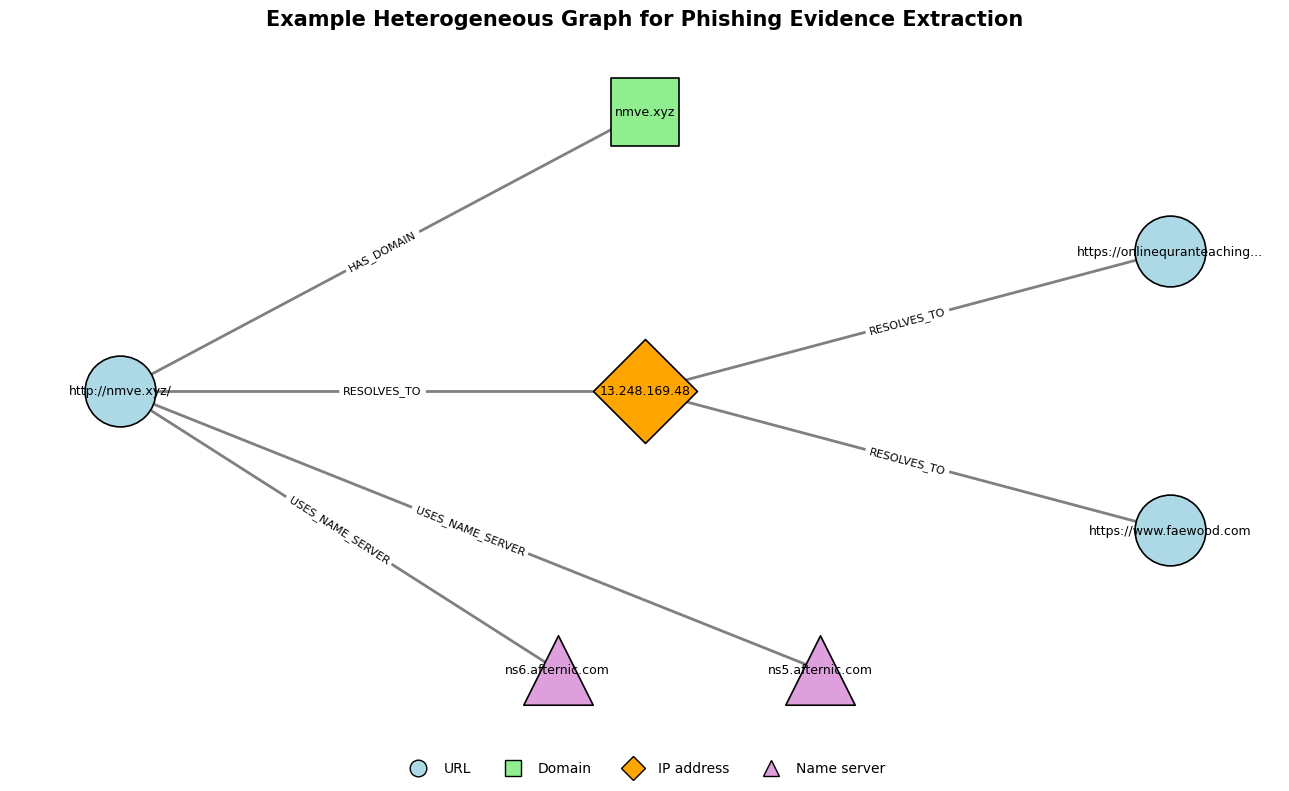

In [22]:
plot_report_graph(
    "http://nmve.xyz/"
)